# CH 6 : DATA-MINING BIAS - THE FOOL'S GOLD OF OBJECTIVE TA

> **Idée centrale :** le biais de minage de données apparaît quand on teste beaucoup de règles, puis qu'on sélectionne uniquement la meilleure comme si son résultat venait forcément d'un vrai edge.

Dans un **backtest**, la règle gagnante peut avoir gagné pour deux raisons très différentes :

- elle possède un **vrai pouvoir prédictif** ;
- elle est simplement la plus chanceuse parmi toutes les règles testées.

L'objectif EBTA est de ne pas confondre ces deux cas.


## 1. Le problème en une phrase

Quand tu testes une seule stratégie, un bon résultat peut déjà être dû au hasard.

Mais quand tu testes **100**, **400**, **1 000** ou **10 000** variantes, le problème explose : il devient presque garanti qu'une variante paraisse excellente par pur hasard.

> **L'Eurêka :** plus tu cherches longtemps, plus tu augmentes la probabilité de trouver une illusion statistique.

Ce n'est pas le backtest positif qui pose problème.

Le vrai problème, c'est la phrase cachée derrière le backtest :

> “J'ai choisi cette règle parce qu'elle était la meilleure parmi beaucoup d'autres.”


## 2. La mécanique du biais

Supposons que toutes les règles testées soient nulles.

Elles n'ont aucun edge réel.

Mathématiquement, cela signifie :

$$
H_0 : \mu \le 0
$$

où $\mu$ représente l'espérance future réelle de la règle.

Même si $H_0$ est vraie pour toutes les règles, certaines vont afficher un profit positif dans l'échantillon par simple **erreur d'échantillonnage**.

Et si tu sélectionnes la meilleure, tu sélectionnes presque forcément la règle qui a reçu le plus gros coup de chance.


## 3. Analogie simple : la loterie des règles nulles

Imagine une loterie avec **400 traders sans talent prédictif**.

Chaque trader lance une pièce pendant une année.

À la fin, certains auront perdu, certains seront proches de zéro, et quelques-uns auront gagné énormément.

Le gagnant n'a pas forcément un edge.

Il est juste le plus chanceux du groupe.

En trading systématique, c'est pareil :

| Situation | Lecture naïve | Lecture EBTA |
|---|---:|---:|
| Une règle fait +48\% | “Elle est excellente” | “Combien de règles ont été testées ?” |
| 400 règles ont été testées | “On a bien cherché” | “Le risque de faux gagnant est énorme” |
| La meilleure est sélectionnée | “C'est notre edge” | “C'est peut-être la meilleure chanceuse” |
| Elle échoue en live | “Le marché a changé” | “Le biais n'a pas été corrigé” |


## 4. Formule intuitive du biais

La performance observée de la règle gagnante peut être vue comme :

$$
\text{Performance observée} = \text{mérite réel} + \text{chance} + \text{biais de sélection}
$$

Si toutes les règles sont nulles, le mérite réel est proche de zéro :

$$
\text{Performance observée} \approx \text{chance} + \text{biais de sélection}
$$

Donc la meilleure règle peut sembler brillante même si son espérance future réelle est médiocre.

> **L'Eurêka final :** le biais de minage ne vient pas seulement du hasard. Il vient du hasard **plus** la sélection du meilleur après coup.


## 5. Simulation Python : 400 règles sans aucun edge

Nous allons simuler exactement l'idée du chapitre.

Hypothèse :

- chaque règle a une espérance réelle de $0$ ;
- les rendements sont du bruit ;
- aucune règle ne possède de talent ;
- pourtant, nous allons sélectionner la meilleure règle du groupe.

Objectif : montrer que la meilleure règle peut afficher une performance impressionnante même quand toutes les règles sont nulles.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Paramètres de la simulation
n_rules = 400          # nombre de règles testées
n_days = 252           # environ une année de trading
mu_real = 0.0          # aucune règle n'a d'edge réel
sigma_daily = 0.01     # volatilité quotidienne simulée de 1%

# Chaque colonne représente une règle de trading artificielle sans edge
returns = np.random.normal(
    loc=mu_real,
    scale=sigma_daily,
    size=(n_days, n_rules)
)

# Performance cumulée de chaque règle
cumulative_returns = (1 + returns).prod(axis=0) - 1

results = pd.DataFrame({
    "rule_id": np.arange(1, n_rules + 1),
    "cumulative_return": cumulative_returns
})

best_rule = results.loc[results["cumulative_return"].idxmax()]

print(f"Nombre de règles testées : {n_rules}")
print(f"Toutes les règles ont une espérance réelle : {mu_real:.2%}")
print(f"Meilleure règle observée : règle #{int(best_rule['rule_id'])}")
print(f"Performance observée de la meilleure règle : {best_rule['cumulative_return']:.2%}")


Nombre de règles testées : 400
Toutes les règles ont une espérance réelle : 0.00%
Meilleure règle observée : règle #317
Performance observée de la meilleure règle : 65.29%


### Interprétation

La meilleure règle a probablement un rendement positif visible.

Mais dans cette simulation, nous savons une chose que le trader réel ne sait généralement pas :

> toutes les règles ont été générées avec une espérance réelle de zéro.

Donc la meilleure règle est un faux champion.

Elle n'a pas gagné parce qu'elle avait un edge.

Elle a gagné parce qu'elle était la plus chanceuse parmi 400 règles.


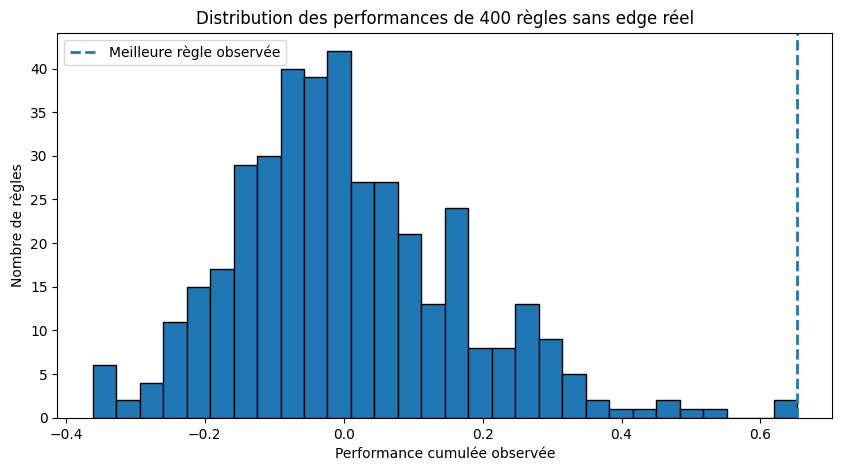

In [8]:
plt.figure(figsize=(10, 5))
plt.hist(results["cumulative_return"], bins=30, edgecolor="black")
plt.axvline(best_rule["cumulative_return"], linestyle="--", linewidth=2, label="Meilleure règle observée")
plt.title("Distribution des performances de 400 règles sans edge réel")
plt.xlabel("Performance cumulée observée")
plt.ylabel("Nombre de règles")
plt.legend()
plt.show()


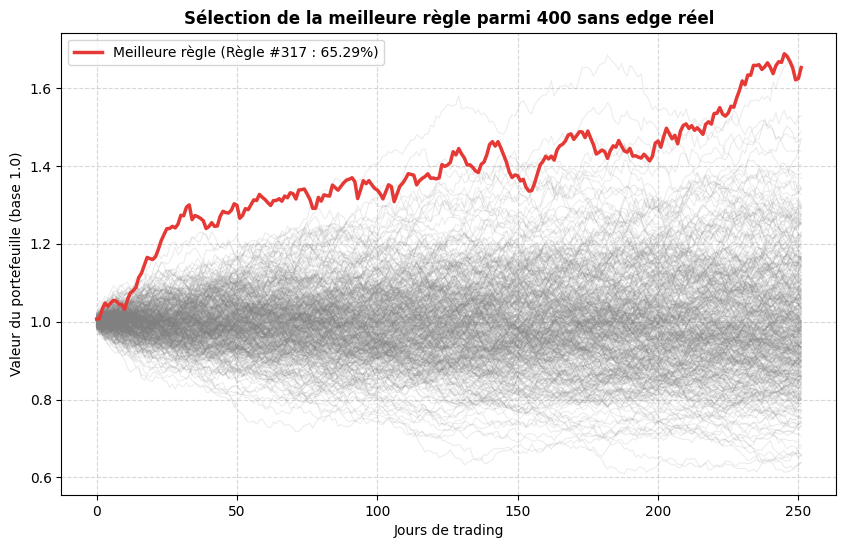

In [9]:
# ------------------------------------------------------------
# Tracé des courbes d'equity (sans recalculs redondants)
# ------------------------------------------------------------

# 1. Calcul des courbes d'equity à partir des rendements existants
# (La variable `returns` provient de la cellule de simulation précédente)
equity_curves = (1 + returns).cumprod(axis=0)

# 2. Identification de l'indice de la meilleure règle
# (On récupère l'ID déjà déterminé par `best_rule` dans la cellule 1)
best_idx = int(best_rule['rule_id']) - 1  # -1 car l'ID commence à 1

# 3. Tracé graphique
plt.figure(figsize=(10, 6))

# Courbes de toutes les stratégies en gris clair (translucide)
for i in range(returns.shape[1]):
    plt.plot(equity_curves[:, i], color='gray', alpha=0.15, linewidth=0.8)

# Mise en évidence de la meilleure règle en rouge vif
plt.plot(equity_curves[:, best_idx], 
         color='#E53935', 
         linewidth=2.5, 
         label=f"Meilleure règle (Règle #{best_idx + 1} : {best_rule['cumulative_return']:.2%})")

plt.title("Sélection de la meilleure règle parmi 400 sans edge réel", fontsize=12, fontweight='bold')
plt.xlabel("Jours de trading")
plt.ylabel("Valeur du portefeuille (base 1.0)")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


## 6. Le nombre de règles testées amplifie le mirage

Maintenant, comparons la meilleure performance obtenue selon le nombre de règles testées.

Nous allons tester :

- 10 règles ;
- 50 règles ;
- 100 règles ;
- 400 règles ;
- 1 000 règles ;
- 5 000 règles.

Toutes les règles restent nulles.

Seul le nombre de tentatives change.


In [10]:
np.random.seed(123)

rule_counts = [10, 50, 100, 400, 1000, 5000]
summary = []

for count in rule_counts:
    simulated_returns = np.random.normal(
        loc=0.0,
        scale=sigma_daily,
        size=(n_days, count)
    )
    cumulative = (1 + simulated_returns).prod(axis=0) - 1
    summary.append({
        "nombre_de_regles": count,
        "meilleure_performance_observee": cumulative.max(),
        "performance_mediane": np.median(cumulative),
        "pire_performance_observee": cumulative.min()
    })

summary_df = pd.DataFrame(summary)
summary_df["meilleure_performance_observee_pct"] = summary_df["meilleure_performance_observee"].map(lambda x: f"{x:.2%}")
summary_df["performance_mediane_pct"] = summary_df["performance_mediane"].map(lambda x: f"{x:.2%}")
summary_df["pire_performance_observee_pct"] = summary_df["pire_performance_observee"].map(lambda x: f"{x:.2%}")

summary_df[[
    "nombre_de_regles",
    "meilleure_performance_observee_pct",
    "performance_mediane_pct",
    "pire_performance_observee_pct"
]]


,nombre_de_regles,meilleure_performance_observee_pct,performance_mediane_pct,pire_performance_observee_pct
0,10,26.19%,-0.48%,-26.62%
1,50,61.04%,3.65%,-27.51%
2,100,54.74%,-0.93%,-31.57%
3,400,52.58%,-2.15%,-37.63%
4,1000,62.59%,-1.10%,-49.38%
5,5000,83.35%,-1.87%,-44.23%


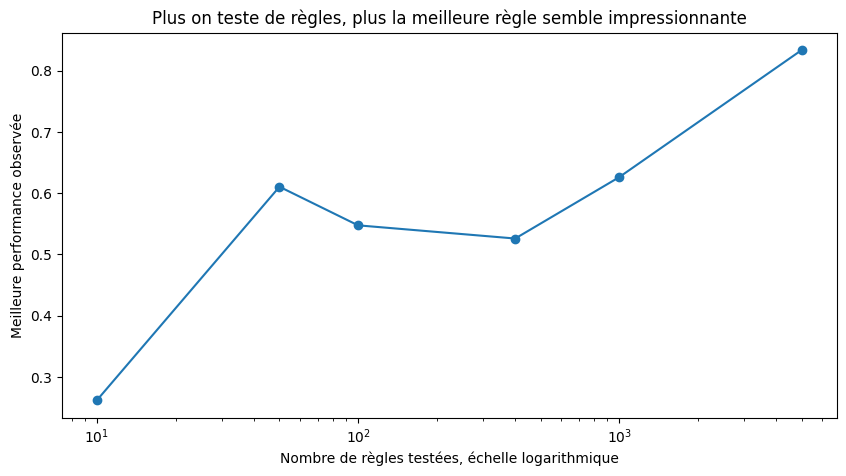

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(
    summary_df["nombre_de_regles"],
    summary_df["meilleure_performance_observee"],
    marker="o"
)
plt.xscale("log")
plt.title("Plus on teste de règles, plus la meilleure règle semble impressionnante")
plt.xlabel("Nombre de règles testées, échelle logarithmique")
plt.ylabel("Meilleure performance observée")
plt.show()


### Ce qu'il faut voir

La performance médiane reste autour de zéro, car les règles n'ont pas d'edge.

Mais la meilleure performance monte quand le nombre de règles augmente.

Ce n'est pas une amélioration du talent.

C'est une augmentation de la probabilité de trouver un extrême chanceux.

> **Phrase de trader d'élite :** “Une performance exceptionnelle n'est pas une preuve si je ne connais pas le nombre total d'essais qui l'ont produite.”


## 7. Les cinq facteurs qui contrôlent le biais

| Facteur | Effet sur le biais | Lecture EBTA |
|---|---:|---|
| **Nombre de règles testées** | Augmente le biais | Plus je teste, plus je dois corriger |
| **Taille de l'échantillon** | Réduit le biais | Plus j'ai de données, moins la chance domine |
| **Corrélation entre règles** | Réduit le nombre effectif de tests | 100 variantes très proches valent moins que 100 règles indépendantes |
| **Outliers** | Peut gonfler artificiellement la moyenne | Un seul événement extrême peut créer un faux edge |
| **Variation du mérite réel** | Peut réduire le biais | Si certaines règles ont vraiment du talent, elles peuvent dominer le bruit |

Le facteur le plus violent est souvent la combinaison :

$$
\text{beaucoup de règles} + \text{petit échantillon} = \text{maximum de mirage}
$$


## 8. Exemple concret en trading

Supposons que tu testes une famille de stratégies basée sur des moyennes mobiles :

- moyenne courte de 5 à 100 ;
- moyenne longue de 20 à 300 ;
- stop-loss de 0.5\% à 5\% ;
- take-profit de 1\% à 10\% ;
- filtres horaires ;
- filtres de volatilité ;
- filtres de tendance.

Même si chaque idée semble raisonnable, le nombre total de combinaisons peut exploser.

Et si tu regardes uniquement la meilleure courbe d'equity, tu risques de tomber amoureux d'un accident.

> **Le piège :** le cerveau voit une belle equity curve. La statistique voit une sélection après optimisation.


## 9. Comment se protéger concrètement

### 9.1 Tenir un journal de recherche

Chaque test compte.

Même les tests abandonnés.

Même les variantes que tu n'as pas aimées.

Même les essais rapides.

Pourquoi ?

Parce que le biais dépend du nombre total de tentatives, pas seulement du nombre de stratégies que tu montres à la fin.

### 9.2 Garder un vrai hors-échantillon

Le **out-of-sample** doit rester caché jusqu'à la fin.

Une seule utilisation.

Pas d'optimisation dessus.

Pas de “je regarde juste vite fait”.

### 9.3 Corriger statistiquement

Des méthodes comme le **White's Reality Check** cherchent à répondre à une question plus honnête :

> “La meilleure règle est-elle encore significative après avoir pris en compte toutes les règles testées ?”

Ce n'est plus une p-value naïve sur une seule règle.

C'est une p-value ajustée pour la réalité du minage.


## 10. Mini-protocole EBTA contre le Fool's Gold

Avant de croire à une stratégie, poser ces questions :

- Combien de règles ou variantes ont réellement été testées ?
- La meilleure règle reste-t-elle bonne hors-échantillon ?
- La stratégie a-t-elle une logique économique plausible ?
- La performance dépend-elle de quelques trades extrêmes ?
- Les règles testées sont-elles très corrélées ou réellement différentes ?
- La p-value a-t-elle été corrigée pour le data mining ?
- Le résultat survit-il à une variation raisonnable des paramètres ?

> **Conclusion clé :** une stratégie n'est pas validée parce qu'elle a gagné dans le passé. Elle est validée quand elle survit à la correction du hasard, de la sélection et de l'optimisation.


## 11. Exercice pratique

Modifie les variables suivantes dans le code :

- `n_rules` ;
- `n_days` ;
- `sigma_daily`.

Observe ce qui se passe.

Tu devrais constater trois choses :

1. plus `n_rules` augmente, plus le meilleur faux gagnant devient impressionnant ;
2. plus `n_days` augmente, plus le bruit se stabilise ;
3. plus `sigma_daily` augmente, plus les extrêmes deviennent spectaculaires.

C'est exactement la logique du biais de minage de données.


In [12]:
def simulate_data_mining_bias(n_rules=400, n_days=252, sigma_daily=0.01, seed=7):
    # Simule le meilleur backtest obtenu parmi des règles sans edge réel.
    rng = np.random.default_rng(seed)
    simulated = rng.normal(0.0, sigma_daily, size=(n_days, n_rules))
    cumulative = (1 + simulated).prod(axis=0) - 1
    return {
        "nombre_de_regles": n_rules,
        "nombre_de_jours": n_days,
        "volatilite_quotidienne": sigma_daily,
        "meilleure_performance": cumulative.max(),
        "performance_moyenne": cumulative.mean(),
        "performance_mediane": np.median(cumulative),
        "pire_performance": cumulative.min()
    }

scenarios = [
    simulate_data_mining_bias(n_rules=50, n_days=252, sigma_daily=0.01, seed=1),
    simulate_data_mining_bias(n_rules=400, n_days=252, sigma_daily=0.01, seed=1),
    simulate_data_mining_bias(n_rules=400, n_days=1000, sigma_daily=0.01, seed=1),
    simulate_data_mining_bias(n_rules=400, n_days=252, sigma_daily=0.02, seed=1),
]

pd.DataFrame(scenarios)


,nombre_de_regles,nombre_de_jours,volatilite_quotidienne,meilleure_performance,performance_moyenne,performance_mediane,pire_performance
0,50,252,0.01,0.267052,-0.016354,-0.024037,-0.422309
1,400,252,0.01,0.634251,-0.009934,-0.021213,-0.393749
2,400,1000,0.01,1.125403,-0.030938,-0.060020,-0.622744
3,400,252,0.02,1.604356,-0.018988,-0.064889,-0.641624


## 12. Résumé final

Le biais de minage de données est dangereux parce qu'il se déguise en preuve objective.

Il donne au trader une règle, une equity curve, un rendement, un Sharpe, un winrate, parfois même une p-value naïve.

Mais il cache la vraie question :

> “Combien de tentatives ont été nécessaires pour obtenir ce résultat ?”

La règle gagnante d'un grand tournoi de règles n'est pas automatiquement une règle talentueuse.

Elle peut être simplement le survivant le plus chanceux.

> **L'Eurêka final :** en EBTA, on ne cherche pas seulement une stratégie qui gagne. On cherche une stratégie qui gagne encore après avoir facturé le coût statistique de toutes les tentatives.


## Annexe : source collée par l'utilisateur

Le texte ci-dessous est conservé comme référence brute pour garder la traçabilité du notebook.



### **CH 6 : DATA-MINING BIAS - THE FOOL'S GOLD OF OBJECTIVE TA**

Ce chapitre traite de l'erreur la plus insidieuse du trading systématique : le biais de minage de données. Il explique pourquoi une règle qui a brillé dans le passé risque fort de s'effondrer dès qu'on l'utilise réellement.,,

#### **(AJOUT) Idées clés :**
*   **Définition du biais :** C'est une erreur systématique où la performance observée de la meilleure règle d'un groupe surestime massivement sa performance future réelle.,,
*   **Le mécanisme du gagnant :** Plus on teste de règles (data mining), plus on a de chances d'en trouver une excellente par pur hasard, sans qu'elle n'ait de talent réel.,,
*   **Les deux coupables :** La détérioration des performances hors-échantillon provient de la combinaison du hasard (chance) et de la logique de sélection (choisir le meilleur),.
*   **L'illusion du profit :** Un backtest positif n'est qu'une condition nécessaire, mais pas suffisante, pour prouver l'efficacité d'une méthode,.

#### **Référence :**
*Data-Mining Bias: The Fool's Gold of Objective TA*, Chapitre 6, pages 255 à 330.,

#### **Citation Directe :**
« The problem is that the winning rule’s observed performance that allowed it to be picked over all other rules systematically overstates how well the rule is likely to perform in the future. This systematic error is the data-mining bias. » (Page 255).

---

#### **Vision Macro :**
L'enjeu est de distinguer l'or véritable du « métal des fous ». David Aronson explique que si le minage de données est une méthode de recherche productive, il est mathématiquement certain de produire des « faux positifs » si l'on ne corrige pas les résultats,. L'esprit humain voit un profit de 37 % et conclut au génie ; l'EBTA voit un profit de 37 % issu de 1 000 tests et conclut probablement à un accident statistique,. Le but est de protéger le capital contre des stratégies qui n'ont « gagné » que parce qu'elles ont eu de la chance lors du backtest.,

---

#### **Vision Micro : Les cinq facteurs déterminants**
Aronson identifie cinq éléments qui font varier l'ampleur du biais :

1.  **Nombre de règles testées :** Plus l'univers de recherche est grand, plus le biais est élevé. Si vous testez 1 000 règles, votre "meilleure" règle sera bien plus biaisée que si vous n'en aviez testé que 10,,.
2.  **Nombre d'observations (Taille de l'échantillon) :** C'est le facteur le plus important. Plus l'historique de données est court, plus la chance peut créer des profits artificiels. Un échantillon large réduit drastiquement le biais via la Loi des Grands Nombres,,.
3.  **Degré de corrélation entre les règles :** Si les règles testées sont très similaires (ex: MA 20 et MA 21), le biais est plus faible car c'est comme si l'on testait moins de règles uniques,.
4.  **Présence de valeurs aberrantes (Outliers) :** Quelques jours de gains extrêmes peuvent fausser la moyenne et faire paraître une règle médiocre comme une gagnante,.
5.  **Variation du mérite réel :** Si toutes les règles sont nulles ($H_0$ vraie), le biais est maximal car le gagnant ne doit tout qu'à la chance. S'il y a de "vraies" bonnes règles dans le lot, le biais diminue car le talent finit par dominer le hasard,.

---

#### **(AJOUT) Résumé Simplifié :**
Le minage de données, c'est comme organiser une loterie géante avec 10 000 perdants. Forcément, l'un d'eux va gagner le gros lot. Si vous engagez ce gagnant en pensant qu'il a "le don de gagner à la loterie", vous faites une erreur de biais de minage. En trading, si vous testez 10 000 indicateurs, l'un d'eux sera forcément "parfait" sur le passé, mais il sera inutile pour l'avenir,.

#### **Exemples du livre pour mieux comprendre :**
*   **Le beurre au Bangladesh :** David Leinweber a trouvé une corrélation de 70 % entre la production de beurre au Bangladesh et l'indice S&P 500. C'est l'exemple parfait du biais de minage : en cherchant parmi des milliers de séries de données absurdes, on finit par trouver une coïncidence frappante qui n'a aucun sens logique ni prédictif,.
*   **L'expérience des ATR (Artificial Trading Rules) :** Aronson utilise des règles artificielles dont il connaît l'espérance de gain (zéro). Il montre que le "meilleur" d'un groupe de 400 règles nulles peut afficher un profit de +48 % par pur hasard,,.

---

#### **Actions Concrètes :**
*   **Appliquer le White's Reality Check :** Utilisez cette méthode pour ajuster la p-value de votre meilleure règle en fonction du nombre total de tests effectués,.
*   **Allonger la période de test :** Ne vous fiez jamais à un backtest sur 2 ans. Visez des décennies de données pour que la Loi des Grands Nombres élimine le bruit,.
*   **Pratiquer le test Hors-Échantillon (Out-of-Sample) :** Gardez une partie des données (ex: les 5 dernières années) "cachées" et ne testez votre meilleure règle dessus qu'une seule fois à la toute fin,.
*   **Tenir un journal de recherche :** Notez *chaque* tentative, paramètre ou indicateur testé. Chaque échec compte dans le calcul du biais final de votre réussite,.

---

#### **(AJOUT) À retenir absolument :**
*   Le profit passé est souvent un **mirage statistique** dû à la sélection du meilleur,.
*   Plus vous cherchez, plus vous avez de chances de trouver du **"Fool's Gold"**,.
*   La **taille de l'échantillon** est votre meilleure défense contre le biais.
*   Une règle qui ne passe pas le **White's Reality Check** doit être ignorée, quel que soit son profit,.
*   La détérioration des gains en live est la conséquence normale d'un **biais non corrigé**,.

J'ai terminé l'analyse du Chapitre 6 sur le biais de minage de données selon le protocole EBTA.
```
